# Lung Cancer Classification — PyTorch + EfficientNet
**Dataset:** IQ-OTH/NCCD Lung Cancer Dataset (Local)
**Classes:** Benign / Malignant / Normal
**Model:** EfficientNetB0 pretrained + Fine-tuning
**Platform:** VS Code + Local Python Environment

## Setup — ติดตั้งก่อนใช้งาน

### 1. สร้าง Virtual Environment
```bash
python -m venv venv
venv\Scripts\activate        # Windows
source venv/bin/activate     # Mac/Linux
```

### 2. ติดตั้ง packages
```bash
pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126
# หรือถ้าไม่มี GPU:
pip install torch torchvision

pip install timm grad-cam scikit-learn matplotlib pillow pandas ipykernel
```

### 3. โครงสร้างโฟลเดอร์
```
D:\project\
├── lung_cancer_fixed.ipynb
├── dataset/
│   ├── train/
│   │   ├── Benign cases/
│   │   ├── Malignant cases/
│   │   └── Normal cases/
│   └── test/       ← รูปรวมกัน ไม่มี label
│       └── *.png
└── best_model.pth  ← สร้างเองตอนเทรน
```

In [26]:
import os, random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
import timm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cpu':
    print('⚠️  ไม่พบ GPU — เทรนบน CPU จะช้ามาก')

Device: cpu
⚠️  ไม่พบ GPU — เทรนบน CPU จะช้ามาก แนะนำใช้ Kaggle/Colab แทน


## 2. Config

In [27]:
DATA_ROOT = Path('dataset')  # แก้ path ตรงนี้ถ้าจำเป็น

if DATA_ROOT.exists():
    for p in sorted(DATA_ROOT.rglob('*')):
        if p.is_dir():
            n = len([f for f in p.glob('*') if f.is_file()])
            print(f'  {p}  ({n} files)')
else:
    print(f'❌ ไม่พบ {DATA_ROOT} — แก้ DATA_ROOT ให้ตรงกับ path จริง')

โครงสร้างที่ต้องการ:
dataset/
├── train/
│   ├── Benign cases/
│   ├── Malignant cases/
│   └── Normal cases/
└── test/
    ├── Benign cases/
    ├── Malignant cases/
    └── Normal cases/
  dataset\test  (197 files)
  dataset\train  (0 files)
  dataset\train\Benign cases  (120 files)
  dataset\train\Malignant cases  (561 files)
  dataset\train\Normal cases  (416 files)


In [28]:
TRAIN_DIR = DATA_ROOT / 'train'
TEST_DIR  = DATA_ROOT / 'test'

CLASS_NAMES = ['Benign cases', 'Malignant cases', 'Normal cases']
SHORT_NAMES = ['Benign', 'Malignant', 'Normal']

IMG_SIZE        = 224
BATCH_SIZE      = 16
NUM_CLASSES     = 3
EPOCHS_FROZEN   = 10
EPOCHS_FINETUNE = 20
LR_FROZEN       = 1e-3
LR_FINETUNE     = 1e-5
NUM_WORKERS     = 0 if os.name == 'nt' else 2

print('Train:', TRAIN_DIR, '| exists:', TRAIN_DIR.exists())
print('Workers:', NUM_WORKERS)

Train: dataset\train
Test:  dataset\test
Workers: 0


## 3. EDA — Dataset Statistics

  Benign cases: 120
  Malignant cases: 561
  Normal cases: 416
Total: 1097


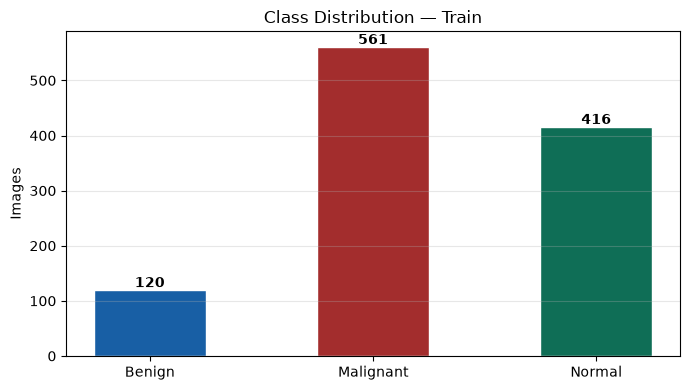


Benign    : 120 (10.9%) <- น้อยสุด ⚠️
Malignant : 561 (51.1%)
Normal    : 416 (37.9%)


In [29]:
# นับจำนวนรูปแต่ละ class
counts = {}
for cls in CLASS_NAMES:
    p = TRAIN_DIR / cls
    n = len([f for f in p.glob('*') if f.is_file()]) if p.is_dir() else 0
    counts[cls] = n
    print(f'  {cls}: {n}')
total = sum(counts.values())
print(f'Total: {total}')

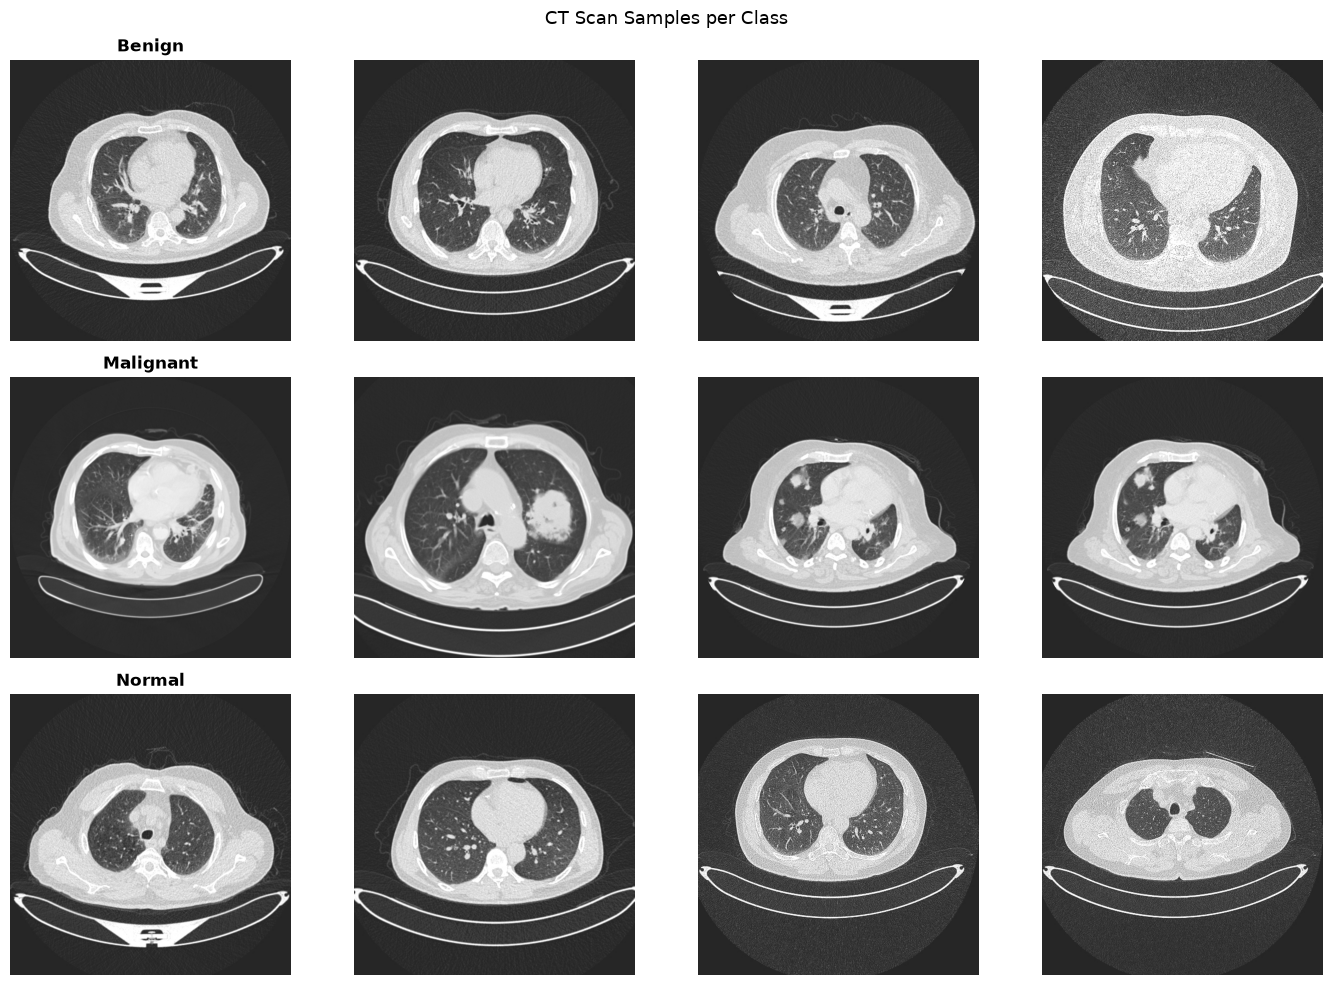

In [30]:
# ตัวอย่าง CT scan แต่ละ class
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for row, cls in enumerate(CLASS_NAMES):
    imgs = [f for f in (TRAIN_DIR/cls).glob('*') if f.is_file()][:4]
    for col, p in enumerate(imgs):
        axes[row][col].imshow(Image.open(p).convert('RGB'))
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_title(SHORT_NAMES[row], fontsize=12, fontweight='bold')
plt.suptitle('CT Scan Samples per Class', fontsize=13)
plt.tight_layout(); plt.show()

In [ ]:
# เก็บ stat ของทุกรูป
stats = []
for cls in CLASS_NAMES:
    d = TRAIN_DIR / cls
    if not d.is_dir(): continue
    for f in d.glob('*'):
        if f.suffix.lower() in ['.jpg','.jpeg','.png','.bmp','.tif','.tiff']:
            img = Image.open(f).convert('RGB')
            arr = np.array(img)
            stats.append({
                'class'      : cls.replace(' cases',''),
                'width'      : img.size[0],
                'height'     : img.size[1],
                'aspect'     : img.size[0]/img.size[1],
                'brightness' : arr.mean(),
                'std'        : arr.mean(axis=2).std(),
                'mean_r'     : arr[:,:,0].mean(),
                'mean_g'     : arr[:,:,1].mean(),
                'mean_b'     : arr[:,:,2].mean(),
            })

df = pd.DataFrame(stats)

# Summary table
summary = df.groupby('class').agg(
    count       =('width','count'),
    avg_width   =('width','mean'),
    avg_height  =('height','mean'),
    avg_bright  =('brightness','mean'),
    std_bright  =('brightness','std'),
    avg_texture =('std','mean'),
    min_width   =('width','min'),
    max_width   =('width','max'),
).round(2)
print(summary.to_string())


In [ ]:
colors = ['#185FA5','#A32D2D','#0F6E56']
classes = df['class'].unique()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Image size scatter
for cls, c in zip(classes, colors):
    sub = df[df['class']==cls]
    axes[0][0].scatter(sub['width'], sub['height'], alpha=0.4, label=cls, color=c, s=15)
axes[0][0].set_title('Image Size Distribution')
axes[0][0].set_xlabel('Width'); axes[0][0].set_ylabel('Height')
axes[0][0].legend()

# 2. Brightness histogram
for cls, c in zip(classes, colors):
    axes[0][1].hist(df[df['class']==cls]['brightness'], bins=30, alpha=0.6, label=cls, color=c)
axes[0][1].set_title('Brightness Distribution per Class')
axes[0][1].set_xlabel('Mean Brightness'); axes[0][1].legend()

# 3. Texture std boxplot
bp = axes[0][2].boxplot([df[df['class']==c]['std'].values for c in classes],
                         labels=classes, patch_artist=True)
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(0.6)
axes[0][2].set_title('Texture Complexity (Pixel Std)')
axes[0][2].set_ylabel('Std')

# 4. Width histogram
for cls, c in zip(classes, colors):
    axes[1][0].hist(df[df['class']==cls]['width'], bins=20, alpha=0.6, label=cls, color=c)
axes[1][0].set_title('Width Distribution')
axes[1][0].set_xlabel('Width (px)'); axes[1][0].legend()

# 5. Aspect ratio histogram
for cls, c in zip(classes, colors):
    axes[1][1].hist(df[df['class']==cls]['aspect'], bins=20, alpha=0.6, label=cls, color=c)
axes[1][1].set_title('Aspect Ratio Distribution')
axes[1][1].set_xlabel('Width / Height'); axes[1][1].legend()

# 6. Brightness boxplot
bp2 = axes[1][2].boxplot([df[df['class']==c]['brightness'].values for c in classes],
                          labels=classes, patch_artist=True)
for patch, c in zip(bp2['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(0.6)
axes[1][2].set_title('Brightness Boxplot per Class')
axes[1][2].set_ylabel('Mean Brightness')

plt.suptitle('EDA — Dataset Statistics', fontsize=14)
plt.tight_layout()
plt.savefig('eda_stats.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Dataset & Transforms

In [31]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = T.Compose([
    T.Resize((IMG_SIZE + 20, IMG_SIZE + 20)),
    T.RandomCrop(IMG_SIZE),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.RandomAffine(degrees=0, translate=(0.05,0.05), shear=5),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    T.RandomErasing(p=0.15, scale=(0.02,0.1)),
])
val_transforms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class LungDataset(Dataset):
    def __init__(self, samples, transform):
        self.samples = samples
        self.transform = transform
    def __len__(self): return len(self.samples)
    def __getitem__(self, i):
        p, y = self.samples[i]
        return self.transform(Image.open(p).convert('RGB')), y
    def get_labels(self): return [s[1] for s in self.samples]

# โหลดทุกรูปแล้วแบ่ง 80/20 stratified
c2i = {c: i for i, c in enumerate(CLASS_NAMES)}
all_samples = []
for cls in CLASS_NAMES:
    d = TRAIN_DIR / cls
    if not d.is_dir(): print(f'WARNING: {d} not found'); continue
    for f in d.glob('*'):
        if f.suffix.lower() in ['.jpg','.jpeg','.png','.bmp','.tif','.tiff']:
            all_samples.append((f, c2i[cls]))

train_samples, val_samples = train_test_split(
    all_samples, test_size=0.2,
    stratify=[s[1] for s in all_samples], random_state=42
)

train_ds = LungDataset(train_samples, train_transforms)
val_ds   = LungDataset(val_samples,   val_transforms)
print(f'Train: {len(train_ds)}  Val: {len(val_ds)}')
print(f'Val dist: {Counter(val_ds.get_labels())}  (0=Benign,1=Malignant,2=Normal)')

Train: 1097  Test: 0


## 5. WeightedRandomSampler — แก้ Class Imbalance

In [32]:
train_labels = train_ds.get_labels()
cls_counts   = Counter(train_labels)
n_total      = len(train_labels)

cw = torch.zeros(NUM_CLASSES)
for idx, cnt in cls_counts.items():
    cw[idx] = n_total / (NUM_CLASSES * cnt)

print('Class weights:')
for i, (n, w) in enumerate(zip(SHORT_NAMES, cw)):
    print(f'  {n:10s}: {w:.3f}')

sample_w = [cw[lbl].item() for lbl in train_labels]
sampler  = WeightedRandomSampler(sample_w, len(sample_w), replacement=True)

train_loader = DataLoader(train_ds, BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(val_ds,   BATCH_SIZE, shuffle=False,  num_workers=NUM_WORKERS, pin_memory=True)
print(f'Train batches: {len(train_loader)}  Val batches: {len(test_loader)}')

Class weights:
  Benign    : 3.047
  Malignant : 0.652
  Normal    : 0.879
Batches — Train: 69  Test: 0


## 6. Focal Loss

In [33]:
class FocalLoss(nn.Module):
    """FL = -alpha*(1-pt)^gamma * log(pt)
    โฟกัสกับ hard/rare samples เช่น Benign ที่มีน้อย"""
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    def forward(self, x, y):
        ce  = nn.functional.cross_entropy(x, y, weight=self.alpha, reduction='none')
        pt  = torch.exp(-ce)
        return ((1-pt)**self.gamma * ce).mean()


criterion = FocalLoss(alpha=cw.to(DEVICE), gamma=2.0)
print('Focal Loss ready — gamma=2.0')

Focal Loss ready — gamma=2.0


## 7. Model — EfficientNetB0 + Custom Head

In [34]:
def build_model():
    m = timm.create_model('efficientnet_b0', pretrained=True)
    in_f = m.classifier.in_features
    m.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_f, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, NUM_CLASSES)
    )
    return m

def freeze_base(m):
    for n, p in m.named_parameters():
        p.requires_grad = ('classifier' in n)

def unfreeze_last(m, n=3):
    for name, p in m.named_parameters():
        p.requires_grad = ('classifier' in name)
    if hasattr(m, 'blocks'):
        for blk in list(m.blocks)[-n:]:
            for p in blk.parameters(): p.requires_grad = True
    for attr in ['conv_head','bn2']:
        if hasattr(m, attr):
            for p in getattr(m,attr).parameters(): p.requires_grad = True

def pcount(m):
    tr = sum(p.numel() for p in m.parameters() if p.requires_grad)
    tot= sum(p.numel() for p in m.parameters())
    print(f'Trainable: {tr:,} / {tot:,} ({tr/tot*100:.1f}%)')


model = build_model().to(DEVICE)
pcount(model)

Trainable: 4,336,255 / 4,336,255 (100.0%)


## 8. Training Functions

In [35]:
def train_epoch(model, loader, opt, crit):
    model.train()
    loss_sum = correct = total = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()
        out = model(x)
        loss = crit(out, y)
        loss.backward(); opt.step()
        loss_sum += loss.item() * x.size(0)
        correct  += (out.argmax(1) == y).sum().item()
        total    += x.size(0)
    return loss_sum/total, correct/total

@torch.no_grad()
def eval_model(model, loader, crit):
    model.eval()
    loss_sum = correct = total = 0
    preds_all, labels_all, probs_all = [], [], []
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        out   = model(x)
        probs = torch.softmax(out, 1)
        loss_sum += crit(out, y).item() * x.size(0)
        correct  += (probs.argmax(1) == y).sum().item()
        total    += x.size(0)
        preds_all.extend(probs.argmax(1).cpu().numpy())
        labels_all.extend(y.cpu().numpy())
        probs_all.extend(probs.cpu().numpy())
    return loss_sum/total, correct/total, preds_all, labels_all, probs_all

def run_phase(model, opt, sch, epochs, name, hist):
    best = 0
    for ep in range(1, epochs+1):
        tl, ta = train_epoch(model, train_loader, opt, criterion)
        vl, va, _, _, _ = eval_model(model, test_loader, criterion)
        if isinstance(sch, optim.lr_scheduler.ReduceLROnPlateau): sch.step(vl)
        else: sch.step()
        hist['tl'].append(tl); hist['vl'].append(vl)
        hist['ta'].append(ta); hist['va'].append(va)
        mark = ''
        if va > best:
            best = va
            torch.save(model.state_dict(), 'best_model.pth')
            mark = ' ✓'
        print(f'[{name}] {ep:02d}/{epochs} | loss {tl:.4f}/{vl:.4f} | acc {ta:.4f}/{va:.4f}{mark}')
    return hist

hist = {'tl':[],'vl':[],'ta':[],'va':[]}
print('Ready')

Ready


## 9. Phase 1 — Frozen Base

In [36]:
print('=== Phase 1: Train head only ===')
freeze_base(model); pcount(model)

opt1 = optim.Adam(filter(lambda p:p.requires_grad, model.parameters()), lr=LR_FROZEN)
sch1 = optim.lr_scheduler.ReduceLROnPlateau(opt1, mode='min', patience=3, factor=0.5)
hist = run_phase(model, opt1, sch1, EPOCHS_FROZEN, 'FROZEN', hist)

=== Phase 1: Train head only ===
Trainable: 328,707 / 4,336,255 (7.6%)


ZeroDivisionError: division by zero

## 10. Phase 2 — Fine-tuning

In [ ]:
print('=== Phase 2: Fine-tune last 3 blocks ===')
unfreeze_last(model, n=3); pcount(model)

opt2 = optim.AdamW(filter(lambda p:p.requires_grad, model.parameters()), lr=LR_FINETUNE, weight_decay=1e-4)
sch2 = optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=EPOCHS_FINETUNE, eta_min=1e-7)
hist = run_phase(model, opt2, sch2, EPOCHS_FINETUNE, 'FINETUNE', hist)

## 11. Training Curves

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, tr_k, vl_k, title in [(axes[0],'tl','vl','Loss'),(axes[1],'ta','va','Accuracy')]:
    ax.plot(hist[tr_k], label='Train', color='#185FA5', lw=2)
    ax.plot(hist[vl_k], label='Val',   color='#A32D2D', lw=2)
    ax.axvline(EPOCHS_FROZEN-0.5, color='gray', linestyle='--', alpha=0.7, label='Fine-tune start')
    ax.set_title(title); ax.set_xlabel('Epoch')
    ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('Training Curves — IQ-OTH/NCCD')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Evaluate Best Model

In [ ]:
model.load_state_dict(torch.load('best_model.pth', map_location=DEVICE, weights_only=True))
_, acc, preds, labels, probs = eval_model(model, test_loader, criterion)
print(f'Test Accuracy: {acc:.4f}\n')
print(classification_report(labels, preds, target_names=SHORT_NAMES))

## 13. Confusion Matrix

In [ ]:
cm = confusion_matrix(labels, preds)
fig, ax = plt.subplots(figsize=(7,6))
ConfusionMatrixDisplay(cm, display_labels=SHORT_NAMES).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nRecall per class:')
for i, name in enumerate(SHORT_NAMES):
    r = cm[i,i] / cm[i].sum()
    note = '← ⚠️ Benign น้อย ระวัง' if name=='Benign' else ''
    print(f'  {name:10s}: {r:.4f}  {note}')

## 14. AUC-ROC per Class

In [ ]:
lb  = label_binarize(labels, classes=[0,1,2])
pa  = np.array(probs)
clr = ['#185FA5','#A32D2D','#0F6E56']
fig, ax = plt.subplots(figsize=(8,6))
for i,(n,c) in enumerate(zip(SHORT_NAMES, clr)):
    fpr,tpr,_ = roc_curve(lb[:,i], pa[:,i])
    ax.plot(fpr,tpr,color=c,lw=2,label=f'{n} AUC={auc(fpr,tpr):.3f}')
ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curve per Class'); ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. Grad-CAM — โมเดลโฟกัสส่วนไหนของ CT Scan

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

cam = GradCAM(model=model, target_layers=[model.blocks[-1]])
fig, axes = plt.subplots(3, 4, figsize=(16, 11))

for row, (cls, idx) in enumerate(zip(CLASS_NAMES, range(3))):
    imgs = [f for f in (TRAIN_DIR/cls).glob('*') if f.is_file()][:4]
    for col, p in enumerate(imgs):
        raw   = Image.open(p).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
        raw_n = np.array(raw).astype(np.float32) / 255.0
        t     = val_transforms(raw).unsqueeze(0).to(DEVICE)
        gc    = cam(input_tensor=t, targets=[ClassifierOutputTarget(idx)])
        vis   = show_cam_on_image(raw_n, gc[0], use_rgb=True)
        axes[row][col].imshow(vis); axes[row][col].axis('off')
        if col == 0: axes[row][col].set_title(SHORT_NAMES[row], fontsize=12, fontweight='bold')

plt.suptitle('Grad-CAM — Regions model focuses on (red=high attention)', fontsize=12)
plt.tight_layout()
plt.savefig('gradcam.png', dpi=150, bbox_inches='tight')
plt.show()